### The Jameson Portfolio Optimizer 

This optimizer constructs an active small-cap equity portfolio benchmarked to the Russell 2000. 

#### This optimizer uses the following:
- Expected returns from the BUFC IA / JA / SA pitches (annualized)
- Covariance matrix (Ledoit–Wolf shrinkage)
- A global tracking error constraint vs. the Russell (via ETF sector proxies)
- Soft constraints on sector level deviations
- Hard allocation bands (ETFs vs. stocks, position caps, no leverage)

#### The goal: 
Find a portfolio that maximizes expected active return subject to a chosen tracking-error budget, while keeping exposures economically reasonable and diversified. This is a classic information-ratio maximization problem. 

#### Imports and Path Setup

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
SRC  = ROOT / "src"
DATA = ROOT / "data"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from companies import HOLDINGS_INFO, RUSSELL_SECTOR_WEIGHTS
from portfolio_optimizer import (
    OptimizerBands,
    optimize_quadratic_portfolio,
    run_te_sweep_frontier, 
)
from trade_sheet import build_trade_sheet_from_optimizer_result, TradePlanConfig, save_trade_sheet_csv

In [2]:
prices_path = DATA / "daily_prices.csv"
prices = pd.read_csv(prices_path, parse_dates=["date"]).set_index("date").sort_index()
prices.index = pd.to_datetime(prices.index)

universe = sorted(HOLDINGS_INFO.keys())

missing_cols = [t for t in universe if t not in prices.columns]
print("Price date range:", prices.index.min().date(), "->", prices.index.max().date())

assert not missing_cols, "daily_prices.csv missing tickers in HOLDINGS_INFO"

Price date range: 2025-01-02 -> 2026-01-29


#### Before Running the optimizer 
- [ ] Update HOLDINGS_INFO with desired companies/ETFS, expected returns, expense ratios (ETFs only). 
- [ ] Update RUSSELL_SECTOR_WEIGHTS with live sector weights and change comment to last updated date. 
- [ ] Double check that the daily_prices.csv has no null entries (above will throw an error if null entries exist)
- [ ] Define well thought out risk parameters (Tracking Error cap, ETF vs Stock allocation, position size limits, sector deviation penalty strength)

### Run optimizer

In [10]:
bands = OptimizerBands(
    etf_min=0.20, etf_max=0.30,
    stock_min=0.70, stock_max=0.8,
    max_weight_etf=0.08,
    max_weight_stock=0.05,
    sector_penalty_gamma=4.0, # ideal between 1.0-8.0
)

te_cap = 0.16   # annualized TE cap (try 0.08, 0.10, 0.12)

res = optimize_quadratic_portfolio(
    daily_prices_csv=prices_path,
    holdings_info=HOLDINGS_INFO,
    russell_sector_weights=RUSSELL_SECTOR_WEIGHTS,
    te_cap=te_cap,
    bands=bands,
    lookback_days=252,
    debug=False,   # flip True if you want the stage debug prints
)

assert res is not None, "Optimizer returned None (solver failure)."
print("Solved. TE:", res["te"], "ActiveRet(alpha·w):", res["active_return"], "IR:", res["ir"])


Solved. TE: 0.14305909916016957 ActiveRet(alpha·w): 0.08881681910548665 IR: 0.6208400558013228


If an error is thrown, the most likely cause is too tight of a tracking-error constraint AND/OR too tight of max_weight constraints or ETF/STOCK constraints. 

In [11]:
w = pd.Series(res["weights"]).sort_values(ascending=False)
w = w[w > 1e-6]

df_meta = pd.DataFrame.from_dict(HOLDINGS_INFO, orient="index")
df_meta.index.name = "Ticker"

summary = (
    pd.DataFrame({"Weight": w})
    .join(df_meta[["asset_type", "sector", "expected_return"]], how="left")
    .reset_index()
    .rename(columns={"index": "Ticker"})
)

print("Top holdings:")
display(summary.head(25))

etf_w = float(summary.loc[summary["asset_type"] == "index", "Weight"].sum())
stk_w = float(summary.loc[summary["asset_type"] != "index", "Weight"].sum())
print(f"ETF sleeve:   {etf_w:.1%}")
print(f"Stock sleeve: {stk_w:.1%}")
print(f"Total:        {(etf_w+stk_w):.1%}")


Top holdings:


,Ticker,Weight,asset_type,sector,expected_return
0,RSPF,0.080000,index,Financials,0.10
1,PSCI,0.061315,index,Industrials,0.10
2,PSR,0.057129,index,Real Estate,0.10
3,STEP,0.050000,stock,Financials,0.20
4,EHC,0.050000,stock,Health Care,0.30
5,PRVA,0.050000,stock,Health Care,0.30
6,ENSG,0.050000,stock,Health Care,0.25
7,UAA,0.050000,stock,Consumer Discretionary,0.20
8,NXT,0.050000,stock,Information Technology,0.25
9,ACHR,0.050000,stock,Industrials,0.35


ETF sleeve:   30.0%
Stock sleeve: 70.0%
Total:        100.0%


#### (Optional) Save trade sheet

In [12]:
cfg = TradePlanConfig(lot_size=1, min_trade_value=200.0, cash_buffer=0.02, cash_ticker="CASH")

snap_path   = DATA / "portfolio_snapshot.csv"

sheet = build_trade_sheet_from_optimizer_result(
    res=res,
    portfolio_snapshot_csv=snap_path,
    daily_prices_csv=prices_path,
    cfg=cfg,
)


=== TRADE SHEET (ordered by $ volume) ===
Ticker Action  TradeShares  Price  TradeValue  CurShares  NewShares
  PSCT   SELL    -2,865.00  61.36 -175,786.09   2,865.00       0.00
  KBWR   SELL    -1,226.00  64.83  -79,487.71   1,226.00       0.00
  PSCI   SELL      -448.00 164.44  -73,670.96     933.00     485.00
  PRVA    BUY     2,843.00  22.86   64,990.98       0.00   2,843.00
  ACHR    BUY     8,747.00   7.43   64,990.21       0.00   8,747.00
   UAA    BUY    10,267.00   6.33   64,990.11       0.00  10,267.00
  ELLO    BUY     2,425.00  26.80   64,990.00       0.00   2,425.00
  PATK   SELL      -462.00 128.28  -59,265.36     462.00       0.00
  PSCH   SELL    -1,215.00  44.73  -54,348.53   1,680.00     465.00
   TTC    BUY       589.00  89.96   52,986.44       0.00     589.00
  LASR    BUY     1,099.00  47.11   51,773.89       0.00   1,099.00
  RSPF    BUY       598.00  77.50   46,343.92     744.00   1,342.00
  STEP   SELL      -608.00  73.26  -44,542.08   1,495.00     887.00
  PSC

#### Post-Hoc analysis 

In [13]:
from sklearn.linear_model import LinearRegression

tickers = res["tickers"]
w_b = pd.Series(0.0, index=tickers)

# benchmark is ETF proxy weights by sector (already embedded in res as benchmark_sector_weights)
b_sec = pd.Series(res["benchmark_sector_weights"])
sector_to_etf = {
    meta["sector"]: t
    for t, meta in HOLDINGS_INFO.items()
    if meta.get("asset_type") == "index" and meta.get("sector") is not None
}
for sec, bw in b_sec.items():
    etf = sector_to_etf.get(sec)
    if etf in w_b.index:
        w_b.loc[etf] += float(bw)
w_b = w_b / w_b.sum()

# returns matrix
px = prices[tickers].ffill()
R = px.pct_change().dropna()

# align weights
w_vec = pd.Series(res["weights"]).reindex(tickers).fillna(0.0).to_numpy()
wb_vec = w_b.reindex(tickers).fillna(0.0).to_numpy()

rp = R.to_numpy() @ w_vec
rb = R.to_numpy() @ wb_vec
active = rp - rb

ann_active_mean = float(np.mean(active) * 252.0)
te = float(np.std(active, ddof=1) * np.sqrt(252.0))

# beta of portfolio to benchmark
var_b = float(np.var(rb, ddof=1))
beta = float(np.cov(rp, rb, ddof=1)[0, 1] / var_b) if var_b > 1e-12 else float("nan")

# residual TE from regression rp ~ a + beta*rb
if np.isfinite(beta):
    X = rb.reshape(-1, 1)
    reg = LinearRegression().fit(X, rp)
    resid = rp - reg.predict(X)
    resid_te = float(np.std(resid, ddof=1) * np.sqrt(252.0))
else:
    resid_te = float("nan")

print("REALIZED (ex-post) active mean (ann):", f"{ann_active_mean:.2%}")
print("REALIZED tracking error (ann):       ", f"{te:.2%}")
print("Beta to ETF-benchmark:               ", f"{beta:.3f}")
print("Residual TE (ann):                   ", f"{resid_te:.2%}")


REALIZED (ex-post) active mean (ann): 15.11%
REALIZED tracking error (ann):        8.39%
Beta to ETF-benchmark:                1.112
Residual TE (ann):                    8.10%


Interpretation: 
- TE tells you total active risk vs benchmark.
- Beta tells you how much of your portfolio behaves like the ETF benchmark.
- resid_te tells you how much “idiosyncratic” tracking error remains after stripping the benchmark exposure.

In [14]:
sector_map = {t: HOLDINGS_INFO[t].get("sector") for t in tickers}
ticker_to_col = {t: j for j, t in enumerate(tickers)}

rows = []
variances = []

for sec, bw in b_sec.items():
    bench_etf = sector_to_etf.get(sec)
    if bench_etf is None or bench_etf not in ticker_to_col:
        continue

    idxs = [ticker_to_col[t] for t in tickers if sector_map.get(t) == sec]
    if not idxs:
        continue

    # sector contribution
    Rp = R.to_numpy()[:, idxs] @ w_vec[idxs]
    Rb = float(bw) * R.to_numpy()[:, ticker_to_col[bench_etf]]

    active_sec = Rp - Rb
    te_s = float(np.std(active_sec, ddof=1) * np.sqrt(252.0))
    var_s = float(np.var(active_sec, ddof=1))
    variances.append(var_s)

    port_w_sec = float(np.sum([w.get(t, 0.0) for t in w.index if sector_map.get(t) == sec]))

    rows.append({
        "Sector": sec,
        "Proxy": bench_etf,
        "BenchW": float(bw),
        "PortW": port_w_sec,
        "ActiveContribTE": te_s,
    })

sector_te = pd.DataFrame(rows)
if sector_te.empty:
    print("No sector TE report (missing proxies or sector mapping).")
else:
    total_var = float(np.sum(variances)) if np.sum(variances) > 0 else 1.0
    sector_te["VarShare"] = [float(v/total_var) for v in variances]
    sector_te = sector_te.sort_values(["VarShare", "ActiveContribTE"], ascending=False).reset_index(drop=True)
    display(sector_te)


,Sector,Proxy,BenchW,PortW,ActiveContribTE,VarShare
0,Information Technology,PSCT,0.128689,0.143426,0.042879,0.258455
1,Consumer Discretionary,PSCC,0.113463,0.124665,0.041461,0.241643
2,Industrials,PSCI,0.188549,0.196893,0.039879,0.223554
3,Health Care,PSCH,0.195537,0.212326,0.033798,0.160569
4,Utilities,PSCU,0.035562,0.050000,0.024440,0.083967
5,Financials,RSPF,0.179685,0.130000,0.014867,0.031070
6,Materials,PSCM,0.042027,0.035711,0.001712,0.000412
7,Energy,RSPG,0.054959,0.049851,0.001366,0.000262
8,Real Estate,PSR,0.061529,0.057129,0.000690,0.000067


From this table, we can see: 
- which sectors dominate active risk (VarShare)
- which sectors have the biggest active-risk contribution (ActiveContribTE)
- how far the sector weights are from benchmark (PortW vs BenchW)

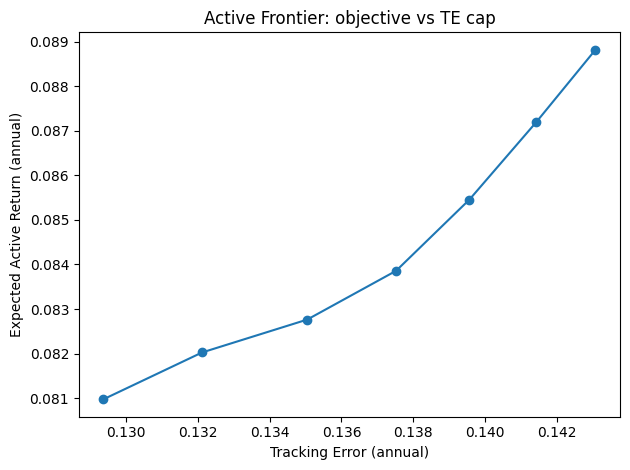

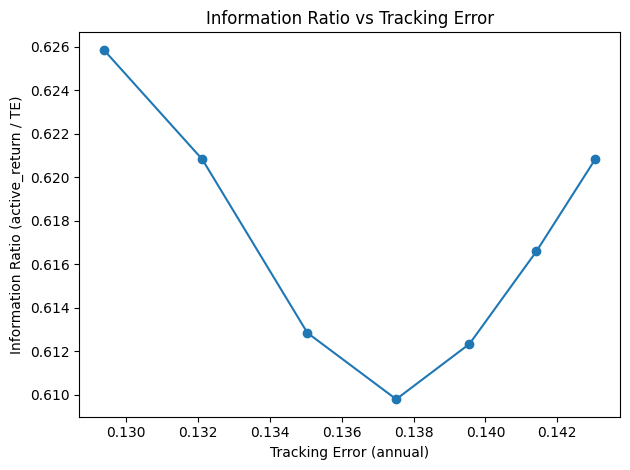

,te_cap,te,active_return,ir,status
45,0.146939,0.135048,0.082763,0.612845,ok
46,0.150204,0.137518,0.083858,0.609793,ok
47,0.153469,0.139556,0.085455,0.612337,ok
48,0.156735,0.141417,0.087196,0.616587,ok
49,0.160000,0.143059,0.088817,0.620840,ok


Best exists? True
Best TE: 0.12938352974608858 Best IR: 0.6258557865820021 Best ActiveRet: 0.08097543077999414


In [15]:
res_sweep = run_te_sweep_frontier(
    daily_prices_csv=prices_path,
    holdings_info=HOLDINGS_INFO,
    russell_sector_weights=RUSSELL_SECTOR_WEIGHTS,
    bands=bands,
    te_min=0.00,
    te_max=0.16,
    te_points=50,
    lookback_days=252,
    debug=False,
    mosek_log=False,
    plot=True,
)

frontier = res_sweep["frontier"]
best = res_sweep["best"]

display(frontier.tail())
print("Best exists?", best is not None)
if best:
    print("Best TE:", best["te"], "Best IR:", best["ir"], "Best ActiveRet:", best["active_return"])